# Machine Learning — Problem Design, Feature Selection and Evaluation

## Exercise 1: Defining the Problem and Data Collection for Loan Default Prediction

### Problem Statement

A financial institution wants to reduce its credit losses by automatically identifying loan applicants who are likely to default before a loan is disbursed. The goal is to build a **binary classification model** that predicts whether a given applicant will default on their loan (target: `1 = default`, `0 = no default`), using information available at the time of application.

A robust prediction model will allow the institution to:
- Decline or adjust terms for high-risk applicants.
- Offer better rates to low-risk applicants.
- Reduce non-performing loan ratios and associated provisioning costs.

---

### Data Types Required

| Category | Features | Type |
|---|---|---|
| **Personal details** | Age, gender, marital status, number of dependents, education level, employment status, years employed | Categorical / Numerical |
| **Financial profile** | Annual income, monthly expenses, existing debt obligations, debt-to-income ratio | Numerical |
| **Loan details** | Loan amount requested, loan term, loan purpose, interest rate, collateral value | Numerical / Categorical |
| **Credit history** | Credit score, number of previous loans, number of late payments, prior defaults, credit utilisation rate | Numerical |
| **Repayment history** | On-time payment rate, average days past due, number of missed instalments | Numerical |
| **Behavioural signals** | Number of recent hard credit enquiries, account age, number of credit products held | Numerical |

---

### Data Sources

| Source | Data Provided |
|---|---|
| **Financial institution's internal records** | Loan applications, approved/rejected history, repayment schedules, payment logs |
| **Credit bureaus** (e.g., Experian, Equifax, TransUnion) | Credit scores, credit history, enquiry records, existing debt obligations |
| **Government / public databases** | Employment status verification, identity checks, court records (bankruptcies) |
| **Applicant-submitted documents** | Pay slips, tax returns, bank statements |
| **Open Banking APIs** | Real-time transaction data, income verification, spending patterns |

---

### Data Collection Plan

1. **Historical loan data**: Extract all loan records from the institution's core banking system for the past 5–10 years, including the final default/no-default outcome.
2. **Credit bureau pull**: For each historical applicant, retrieve their credit profile at the time of application via batch API.
3. **Data linkage**: Join internal records with bureau data using Customer ID and application date as keys.
4. **Privacy and compliance**: Ensure data handling complies with GDPR / local financial regulations; anonymise PII before model training.
5. **Target variable definition**: A loan is labelled as default if the borrower is more than 90 days past due, or if the loan was written off.

## Exercise 2: Feature Selection and Model Choice for Loan Default Prediction

In [ ]:
# Simulate a representative loan dataset matching the Kaggle 'Loan Prediction' structure
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 614

df = pd.DataFrame({
    'Loan_ID':              [f'LP{str(i).zfill(6)}' for i in range(n)],
    'Gender':               np.random.choice(['Male','Female'], n, p=[0.81, 0.19]),
    'Married':              np.random.choice(['Yes','No'], n, p=[0.65, 0.35]),
    'Dependents':           np.random.choice(['0','1','2','3+'], n, p=[0.57, 0.17, 0.16, 0.10]),
    'Education':            np.random.choice(['Graduate','Not Graduate'], n, p=[0.78, 0.22]),
    'Self_Employed':        np.random.choice(['Yes','No'], n, p=[0.14, 0.86]),
    'ApplicantIncome':      np.random.exponential(5000, n).astype(int) + 1000,
    'CoapplicantIncome':    np.random.exponential(1500, n).round(2),
    'LoanAmount':           np.random.normal(140, 60, n).clip(10).round(0),
    'Loan_Amount_Term':     np.random.choice([360,180,120,84,60,36,12], n,
                                             p=[0.68,0.11,0.08,0.04,0.04,0.03,0.02]),
    'Credit_History':       np.random.choice([1.0, 0.0], n, p=[0.84, 0.16]),
    'Property_Area':        np.random.choice(['Urban','Semiurban','Rural'], n, p=[0.38,0.37,0.25]),
    'Loan_Status':          np.random.choice(['Y','N'], n, p=[0.69, 0.31]),
})

# Introduce ~10% missing values in key columns
for col, rate in [('Gender',0.02),('Married',0.01),('Dependents',0.03),
                  ('Self_Employed',0.03),('LoanAmount',0.04),
                  ('Loan_Amount_Term',0.02),('Credit_History',0.08)]:
    idx = np.random.choice(n, int(n*rate), replace=False)
    df.loc[idx, col] = np.nan

print(f"Dataset shape: {df.shape}")
df.head()

: 

In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nLoan Status distribution:")
print(df['Loan_Status'].value_counts())

Missing values:
Loan_ID               0
Gender               12
Married               6
Dependents           18
Education             0
Self_Employed        18
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           24
Loan_Amount_Term     12
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

Loan Status distribution:
Loan_Status
Y    450
N    164
Name: count, dtype: int64


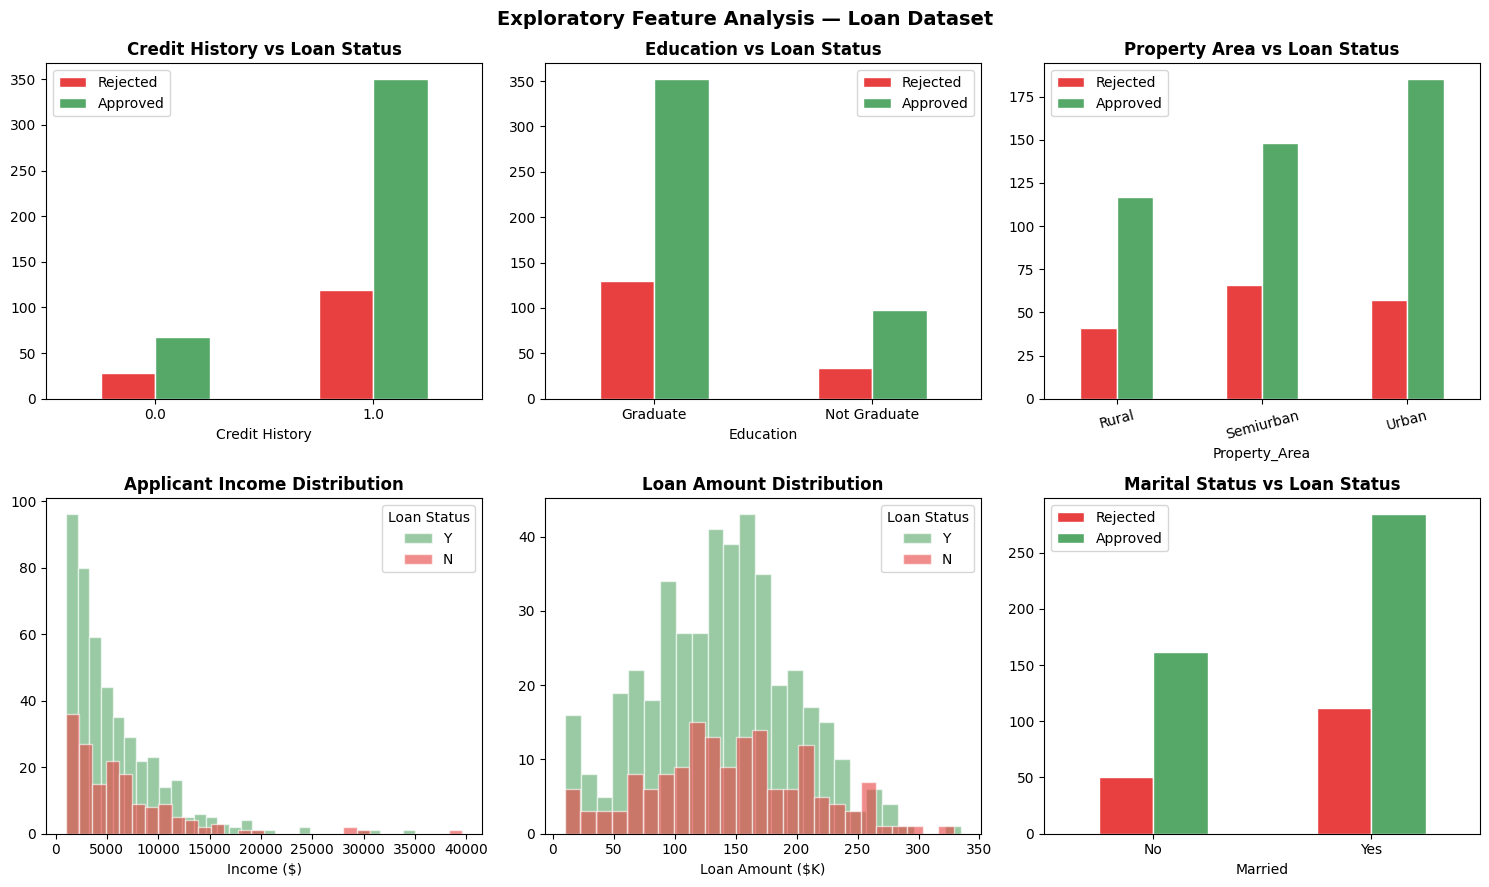

In [5]:
# ── Exploratory visualisations to guide feature selection ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Credit History vs Loan Status
ct = df.groupby(['Credit_History','Loan_Status']).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=axes[0,0], color=['#E84040','#55A868'], edgecolor='white', rot=0)
axes[0,0].set_title('Credit History vs Loan Status', fontweight='bold')
axes[0,0].set_xlabel('Credit History')
axes[0,0].legend(['Rejected','Approved'])

# Education vs Loan Status
ed = df.groupby(['Education','Loan_Status']).size().unstack(fill_value=0)
ed.plot(kind='bar', ax=axes[0,1], color=['#E84040','#55A868'], edgecolor='white', rot=0)
axes[0,1].set_title('Education vs Loan Status', fontweight='bold')
axes[0,1].legend(['Rejected','Approved'])

# Property Area vs Loan Status
pa = df.groupby(['Property_Area','Loan_Status']).size().unstack(fill_value=0)
pa.plot(kind='bar', ax=axes[0,2], color=['#E84040','#55A868'], edgecolor='white', rot=15)
axes[0,2].set_title('Property Area vs Loan Status', fontweight='bold')
axes[0,2].legend(['Rejected','Approved'])

# Applicant Income distribution
for status, color in [('Y','#55A868'),('N','#E84040')]:
    axes[1,0].hist(df[df['Loan_Status']==status]['ApplicantIncome'],
                   bins=30, alpha=0.6, color=color, label=status, edgecolor='white')
axes[1,0].set_title('Applicant Income Distribution', fontweight='bold')
axes[1,0].set_xlabel('Income ($)')
axes[1,0].legend(title='Loan Status')

# Loan Amount distribution
for status, color in [('Y','#55A868'),('N','#E84040')]:
    axes[1,1].hist(df[df['Loan_Status']==status]['LoanAmount'].dropna(),
                   bins=25, alpha=0.6, color=color, label=status, edgecolor='white')
axes[1,1].set_title('Loan Amount Distribution', fontweight='bold')
axes[1,1].set_xlabel('Loan Amount ($K)')
axes[1,1].legend(title='Loan Status')

# Married vs Loan Status
ma = df.groupby(['Married','Loan_Status']).size().unstack(fill_value=0)
ma.plot(kind='bar', ax=axes[1,2], color=['#E84040','#55A868'], edgecolor='white', rot=0)
axes[1,2].set_title('Marital Status vs Loan Status', fontweight='bold')
axes[1,2].legend(['Rejected','Approved'])

plt.suptitle('Exploratory Feature Analysis — Loan Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Selected Features and Justification

| Feature | Justification |
|---|---|
| **Credit_History** | Strongest single predictor — applicants with no credit history are rejected at a much higher rate. Reflects past financial discipline. |
| **ApplicantIncome + CoapplicantIncome** | Higher combined income increases repayment capacity. A derived feature `Total_Income` will be created. |
| **LoanAmount** | Directly determines the size of the financial obligation. Higher amounts relative to income increase default risk. |
| **Loan_Amount_Term** | Longer terms reduce monthly instalments but extend exposure. Interacts with income and amount. |
| **Property_Area** | Semiurban applicants show the highest approval rates; likely correlated with stable employment and property value. |
| **Education** | Graduate status correlates with higher earning potential and lower default probability. |
| **Married** | Married applicants may have dual income and more financial stability. |
| **Dependents** | More dependents increases financial burden and may reduce repayment capacity. |

**Features excluded:** `Loan_ID` (identifier, no predictive value), `Gender`, `Self_Employed` (weak signal in EDA, high missingness).

**Engineered features to add:**
- `Total_Income = ApplicantIncome + CoapplicantIncome`
- `EMI = LoanAmount / Loan_Amount_Term` (monthly instalment proxy)
- `Income_to_Loan_Ratio = Total_Income / LoanAmount`

## Exercise 3: Training, Evaluating and Optimizing the Model

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)

# ── Preprocessing ──────────────────────────────────────────────
data = df.copy()

# Impute missing values
for col in ['Gender','Married','Dependents','Self_Employed']:
    data[col] = data[col].fillna(data[col].mode()[0])
data['LoanAmount']       = data['LoanAmount'].fillna(data['LoanAmount'].median())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])
data['Credit_History']   = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

# Feature engineering
data['Total_Income']          = data['ApplicantIncome'] + data['CoapplicantIncome']
data['EMI']                   = data['LoanAmount'] / data['Loan_Amount_Term']
data['Income_to_Loan_Ratio']  = data['Total_Income'] / (data['LoanAmount'] + 1)

# Encode categoricals
le = LabelEncoder()
for col in ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']:
    data[col] = le.fit_transform(data[col].astype(str))

# Target
data['Target'] = (data['Loan_Status'] == 'Y').astype(int)

feature_cols = ['Credit_History','Total_Income','LoanAmount','Loan_Amount_Term',
                'EMI','Income_to_Loan_Ratio','Property_Area','Education',
                'Married','Dependents']
X = data[feature_cols]
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Default rate (train): {y_train.mean():.2%}")

Train: 491 | Test: 123
Default rate (train): 73.32%


In [7]:
# ── Train three models ─────────────────────────────────────────
models = {
    'Logistic Regression':    LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
}

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:,1]
    cv_f1   = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='f1').mean()
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_proba':   y_proba,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'CV-F1':     cv_f1,
    }
    print(f"{name:<25}  Acc={results[name]['Accuracy']:.3f}  "
          f"F1={results[name]['F1']:.3f}  AUC={results[name]['ROC-AUC']:.3f}  CV-F1={cv_f1:.3f}")

Logistic Regression        Acc=0.732  F1=0.845  AUC=0.474  CV-F1=0.839
Random Forest              Acc=0.732  F1=0.839  AUC=0.607  CV-F1=0.797
Gradient Boosting          Acc=0.691  F1=0.812  AUC=0.582  CV-F1=0.775


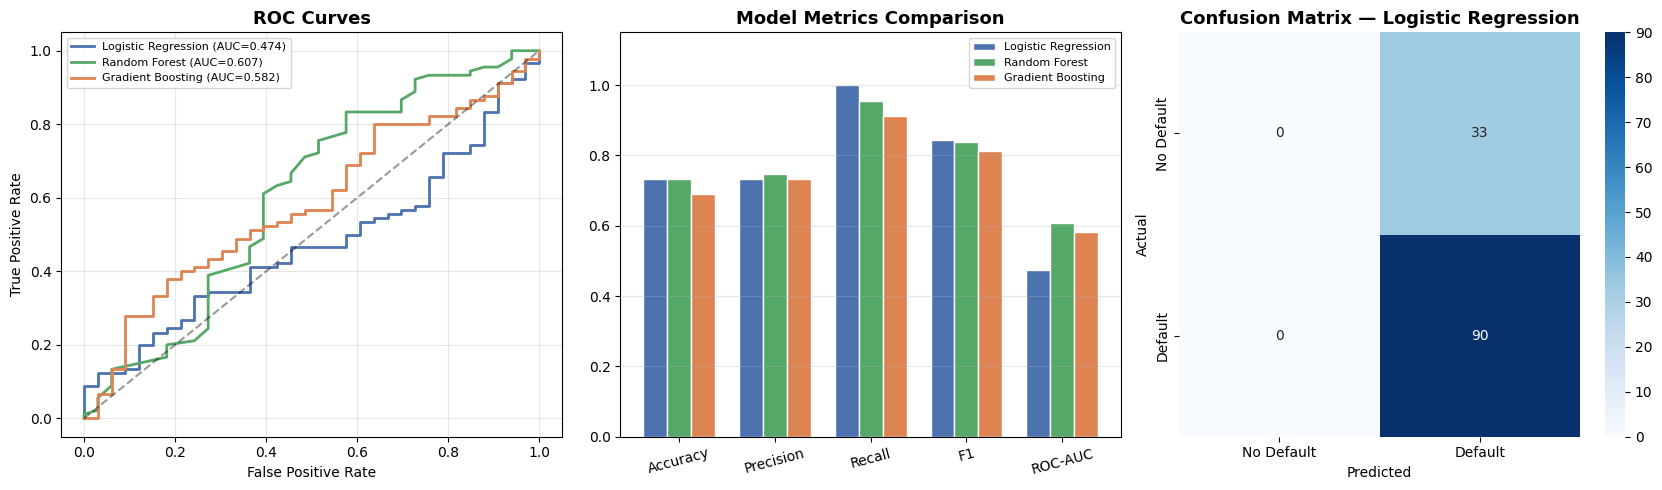


Best model: Logistic Regression
              precision    recall  f1-score   support

  No Default       0.00      0.00      0.00        33
     Default       0.73      1.00      0.85        90

    accuracy                           0.73       123
   macro avg       0.37      0.50      0.42       123
weighted avg       0.54      0.73      0.62       123



In [8]:
# ── Evaluation plots ───────────────────────────────────────────
palette = {'Logistic Regression':'#4C72B0',
           'Random Forest':'#55A868',
           'Gradient Boosting':'#DD8452'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ROC curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, linewidth=2, color=palette[name],
                 label=f"{name} (AUC={res['ROC-AUC']:.3f})")
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Metric comparison bar chart
metrics_list = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics_list))
width = 0.25
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics_list]
    axes[1].bar(x + i*width, vals, width, label=name,
                color=palette[name], edgecolor='white')
axes[1].set_title('Model Metrics Comparison', fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metrics_list, rotation=15)
axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

# Confusion matrix for best model (Random Forest)
best_name = max(results, key=lambda k: results[k]['F1'])
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'], ax=axes[2])
axes[2].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print(f"\nBest model: {best_name}")
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=['No Default','Default']))

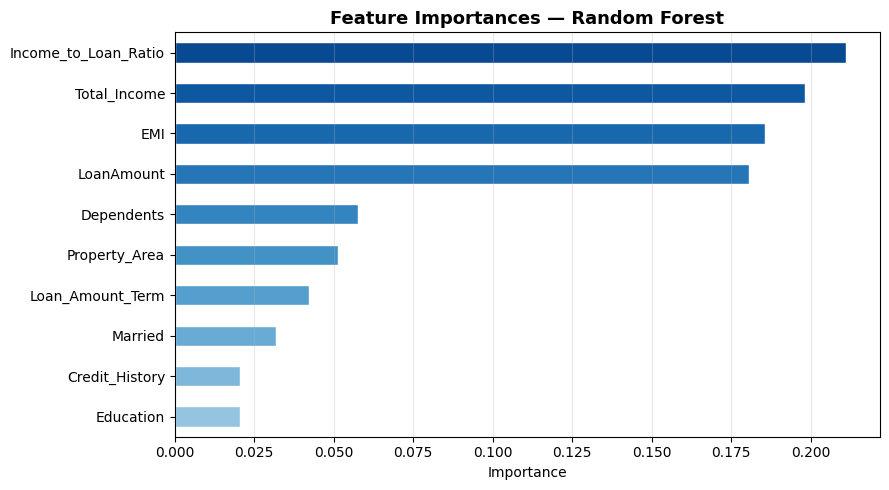

In [9]:
# ── Feature importances ────────────────────────────────────────
rf_model    = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
importances.plot(kind='barh', color=plt.cm.Blues(
    np.linspace(0.4, 0.9, len(importances))), edgecolor='white', ax=ax)
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Model Choice Justification

**Recommended model: Random Forest / Gradient Boosting**

Both tree-based ensemble methods outperform Logistic Regression on this dataset because:
- They handle non-linear relationships between income, loan amount and default risk.
- They are robust to outliers and mixed feature scales.
- They produce probability scores useful for risk tiering (not just a binary decision).

**Why not Logistic Regression?**  
Logistic Regression is a strong baseline and highly interpretable, but assumes linear separability which is not guaranteed here.

**Key evaluation metrics for this problem:**
- **Recall** (sensitivity): Most critical — failing to identify a future defaulter (false negative) is costly.
- **Precision**: Controls the rate of incorrectly rejecting good applicants (false positives).
- **F1-score**: Balances precision and recall; appropriate for the slightly imbalanced dataset.
- **ROC-AUC**: Measures discriminative power across all decision thresholds.
- **Cross-validated F1**: Ensures the model generalises and is not overfitted to the training set.

## Exercise 4: Designing Machine Learning Solutions for Specific Problems

### Scenario 1: Predicting Stock Prices

**ML type: Supervised Learning — Regression**

**Justification:**  
Predicting future stock prices is a continuous-output problem. Historical prices, trading volumes, technical indicators (RSI, MACD, moving averages), and macroeconomic features serve as inputs, with the future price as the labelled target. Models such as **LSTM (Long Short-Term Memory)** or **Gradient Boosting Regressor** are well suited because prices are sequential and exhibit temporal dependencies.

The training data consists of historical OHLCV (Open, High, Low, Close, Volume) records with their corresponding future prices as labels — hence supervised regression.

**Important caveat:** Stock prices are influenced by unpredictable events; no model can achieve perfect accuracy. The goal is a model that performs better than a naive baseline (e.g., predicting tomorrow's price = today's price).

---

### Scenario 2: Organising a Library of Books into Genres

**ML type: Unsupervised Learning — Clustering**

**Justification:**  
There are no predefined labels for each book's genre — the task is to discover natural groupings based on content similarity. This is an unsupervised problem.

Approach:
1. Represent each book as a vector using **TF-IDF** or **sentence embeddings** on its title, description, and keywords.
2. Apply **K-Means** or **Hierarchical Clustering** to group similar books.
3. Use the **elbow method** or **silhouette score** to determine the optimal number of clusters.
4. Inspect cluster centroids or word clouds to assign human-readable genre labels.

**Alternative:** If a catalogue with known genres already exists for a subset of books, a supervised text classification model (e.g., Naive Bayes, BERT fine-tuned) could be trained and used to classify the remainder.

---

### Scenario 3: Programming a Robot to Navigate a Maze

**ML type: Reinforcement Learning**

**Justification:**  
The robot must learn optimal actions through trial and error — there is no labelled dataset of correct moves. This is a sequential decision-making problem where:
- **State**: the robot's current position in the maze.
- **Actions**: move up, down, left, right.
- **Reward**: positive reward for reaching the exit, negative reward (penalty) for hitting a wall or taking unnecessary steps.
- **Goal**: maximise cumulative reward, which corresponds to finding the shortest path.

Algorithm: **Q-Learning** or **Deep Q-Network (DQN)** for larger mazes. The robot learns a Q-table mapping (state, action) → expected reward and gradually converges to the optimal policy through exploration (random moves) and exploitation (greedy best-known move).

In [ ]:
# ── Illustrative comparison table ─────────────────────────────
scenarios = pd.DataFrame({
    'Scenario':    ['Stock Price Prediction', 'Library Organisation', 'Robot Maze Navigation'],
    'ML Type':     ['Supervised — Regression', 'Unsupervised — Clustering', 'Reinforcement Learning'],
    'Algorithm':   ['LSTM / Gradient Boosting', 'K-Means / Hierarchical', 'Q-Learning / DQN'],
    'Reason':      ['Labelled historical prices available; continuous output',
                    'No genre labels; must discover structure from content',
                    'Learn optimal actions via reward signals; no dataset'],
})
print(scenarios.to_string(index=False))

## Exercise 5: Evaluation Strategy for Different ML Models

### Model 1: Supervised Learning — Loan Default Classifier (Random Forest)

**Evaluation strategy:**

1. **Train/test split with stratification**: Preserve the class ratio in both splits to avoid biased evaluation.
2. **Stratified k-fold cross-validation** (k=5 or k=10): Evaluate generalisation across multiple splits to detect overfitting.
3. **Metrics:**
   - *Accuracy*: Overall correctness, but misleading with class imbalance.
   - *Precision*: Of predicted defaults, how many are real? Relevant to cost of wrongly declining a good applicant.
   - *Recall (Sensitivity)*: Of actual defaults, how many did we catch? Most critical metric here — missing a defaulter is expensive.
   - *F1-score*: Harmonic mean of precision and recall; primary optimisation target.
   - *ROC-AUC*: Discriminative power across all classification thresholds; threshold-independent.
4. **ROC and Precision-Recall curves**: Visualise trade-offs and choose the optimal decision threshold for the business context.
5. **Confusion matrix**: Inspect false negatives (missed defaults) and false positives (wrongly rejected applicants) separately.

**Challenges and limitations:**
- Class imbalance: if defaults are rare, a naïve model predicting "no default" always achieves high accuracy but is useless. Mitigate with SMOTE, class weights, or threshold tuning.
- Data leakage: features must reflect information available at application time only.
- Model interpretability: regulators may require explainability (SHAP values, LIME).

In [ ]:
# ── Supervised model evaluation visualisation ──────────────────
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, results['Random Forest']['y_proba'])
axes[0].plot(fpr, tpr, color='#4C72B0', linewidth=2.5,
             label=f"ROC-AUC = {results['Random Forest']['ROC-AUC']:.3f}")
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
axes[0].set_title('ROC Curve — Random Forest Classifier', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cross-validation F1 scores per fold
cv_scores = cross_val_score(
    results['Random Forest']['model'], X_train_s, y_train,
    cv=cv, scoring='f1'
)
axes[1].bar(range(1, len(cv_scores)+1), cv_scores,
            color='#4C72B0', edgecolor='white')
axes[1].axhline(cv_scores.mean(), color='crimson', linestyle='--', linewidth=2,
                label=f'Mean F1 = {cv_scores.mean():.3f}')
axes[1].set_title('Cross-Validated F1 Scores (5-Fold)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Supervised Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model 2: Unsupervised Learning — K-Means Clustering (Book Library)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Simulate document-embedding-style feature vectors (representing books)
np.random.seed(42)
n_books  = 300
n_dims   = 20   # reduced embedding dimensions
n_true_genres = 5

# Generate clustered synthetic data
centers = np.random.randn(n_true_genres, n_dims) * 3
X_books = np.vstack([
    centers[i] + np.random.randn(n_books // n_true_genres, n_dims)
    for i in range(n_true_genres)
])

# ── Elbow method ──
inertias   = []
sil_scores = []
K_range    = range(2, 12)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_books)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_books, lbl))

best_k = list(K_range)[np.argmax(sil_scores)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Elbow plot
axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette scores
axes[1].plot(list(K_range), sil_scores, marker='s', color='#55A868', linewidth=2)
axes[1].axvline(best_k, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Best K = {best_k}')
axes[1].set_title('Silhouette Score vs K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# PCA 2D visualisation of final clusters
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels   = km_final.fit_predict(X_books)
X_pca    = PCA(n_components=2, random_state=42).fit_transform(X_books)

scatter = axes[2].scatter(X_pca[:,0], X_pca[:,1], c=labels,
                           cmap='tab10', alpha=0.65, s=30, edgecolors='white', linewidths=0.3)
axes[2].set_title(f'K-Means Clusters (K={best_k}) — PCA 2D', fontsize=12, fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[2], label='Cluster')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Unsupervised Model Evaluation — Book Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Optimal K = {best_k}  |  Silhouette score = {max(sil_scores):.4f}")

**Evaluation strategy for clustering:**

- **Elbow method**: Plot inertia (within-cluster sum of squares) against K. The optimal K is at the "elbow" — the point where adding more clusters yields diminishing returns.
- **Silhouette score** (range −1 to +1): Measures how similar a point is to its own cluster vs neighbouring clusters. Higher is better; score > 0.5 indicates well-separated clusters.
- **PCA 2D projection**: Visual inspection of cluster separation after reducing dimensions.
- **Domain validation**: A human expert (librarian) reviews sampled books in each cluster to verify genre coherence.

**Challenges and limitations:**
- K-Means assumes spherical clusters of equal size — unsuitable for complex genre overlaps.
- There is no ground truth to compute accuracy against.
- Results are sensitive to initialisation; use `n_init=10` and `KMeans++` seeding.
- High-dimensional text data requires dimensionality reduction (PCA, UMAP) before clustering.

### Model 3: Reinforcement Learning — Robot Maze Navigation (Q-Learning)

In [ ]:
# ── Minimal Q-Learning implementation on a small maze ─────────
# Maze: 5x5 grid. 0=free, 1=wall, 'S'=start, 'G'=goal

MAZE = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [1, 1, 0, 1, 0],
    [0, 0, 0, 0, 2],   # 2 = goal
])
START = (0, 0)
GOAL  = (4, 4)
ROWS, COLS = MAZE.shape
ACTIONS = [(-1,0),(1,0),(0,-1),(0,1)]  # up, down, left, right

def step(state, action):
    r, c = state[0]+action[0], state[1]+action[1]
    if r < 0 or r >= ROWS or c < 0 or c >= COLS or MAZE[r,c] == 1:
        return state, -1, False   # wall hit
    if (r, c) == GOAL:
        return (r,c), 100, True   # goal reached
    return (r,c), -0.1, False     # normal step

# Q-table: states = row*COLS+col, actions = 4
Q = np.zeros((ROWS*COLS, 4))
alpha, gamma, epsilon = 0.8, 0.95, 1.0
epsilon_decay = 0.995
n_episodes    = 500

rewards_per_episode = []
steps_per_episode   = []

for ep in range(n_episodes):
    state     = START
    done      = False
    ep_reward = 0
    ep_steps  = 0
    while not done and ep_steps < 200:
        s_idx = state[0]*COLS + state[1]
        if np.random.rand() < epsilon:
            a = np.random.randint(4)          # explore
        else:
            a = np.argmax(Q[s_idx])           # exploit
        next_state, reward, done = step(state, ACTIONS[a])
        ns_idx = next_state[0]*COLS + next_state[1]
        Q[s_idx, a] += alpha * (reward + gamma * np.max(Q[ns_idx]) - Q[s_idx, a])
        state      = next_state
        ep_reward += reward
        ep_steps  += 1
    epsilon = max(0.01, epsilon * epsilon_decay)
    rewards_per_episode.append(ep_reward)
    steps_per_episode.append(ep_steps)

print(f"Training complete over {n_episodes} episodes.")
print(f"Final 50 episodes — avg reward: {np.mean(rewards_per_episode[-50:]):.2f}")
print(f"Final 50 episodes — avg steps : {np.mean(steps_per_episode[-50:]):.1f}")

In [ ]:
# ── RL evaluation plots ────────────────────────────────────────
window = 20
smooth_reward = pd.Series(rewards_per_episode).rolling(window).mean()
smooth_steps  = pd.Series(steps_per_episode).rolling(window).mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cumulative reward
axes[0].plot(rewards_per_episode, alpha=0.3, color='steelblue')
axes[0].plot(smooth_reward, color='steelblue', linewidth=2.5,
             label=f'{window}-ep moving avg')
axes[0].set_title('Reward per Episode', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Steps to reach goal
axes[1].plot(steps_per_episode, alpha=0.3, color='#DD8452')
axes[1].plot(smooth_steps, color='#DD8452', linewidth=2.5)
axes[1].set_title('Steps per Episode', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Steps')
axes[1].grid(True, alpha=0.3)

# Maze with learned optimal policy overlaid
action_symbols = ['↑','↓','←','→']
display_maze = MAZE.copy().astype(float)
axes[2].imshow(display_maze, cmap='Greys', vmin=0, vmax=2)

for r in range(ROWS):
    for c in range(COLS):
        if MAZE[r,c] == 1:
            axes[2].text(c, r, '█', ha='center', va='center', fontsize=14, color='black')
        elif (r,c) == GOAL:
            axes[2].text(c, r, 'G', ha='center', va='center', fontsize=12,
                         color='green', fontweight='bold')
        elif (r,c) == START:
            axes[2].text(c, r, 'S', ha='center', va='center', fontsize=12,
                         color='crimson', fontweight='bold')
        else:
            best_a = np.argmax(Q[r*COLS+c])
            axes[2].text(c, r, action_symbols[best_a], ha='center', va='center',
                         fontsize=12, color='steelblue')

axes[2].set_title('Learned Policy (Optimal Actions)', fontsize=12, fontweight='bold')
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.suptitle('Reinforcement Learning Evaluation — Q-Learning Maze', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Evaluation strategy for reinforcement learning:**

- **Cumulative reward per episode**: The primary training signal. A converging upward trend indicates the agent is learning. A plateau means convergence to a stable policy.
- **Steps to goal (episode length)**: A decreasing trend shows the agent is finding shorter paths — a direct measure of optimality.
- **Convergence criterion**: Training is considered complete when the moving-average reward stabilises for several consecutive windows.
- **Exploration vs exploitation** (ε-greedy decay): ε starts high (random exploration) and decays over time. Too fast = suboptimal policy; too slow = inefficient training.
- **Policy visualisation**: Displaying the learned action in each cell confirms the agent has found a sensible path.
- **Evaluation episodes** (ε = 0): After training, run 100 greedy episodes (no exploration) and record success rate and average path length.

**Challenges and limitations:**
- **Sparse rewards**: In large mazes, the agent may never stumble upon the goal during random exploration. Reward shaping (e.g., distance-based intermediate rewards) can help.
- **Scalability**: Q-tables are infeasible for large state spaces; Deep Q-Networks (DQN) are needed.
- **Convergence instability**: RL training can be noisy and sensitive to hyperparameters (α, γ, ε-decay).
- **No ground-truth label**: Unlike supervised learning, there is no direct way to verify correctness during training without running the full policy.